# CELL 1 — Imports & Load Data for EAD Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv('../data/cleaned_loan_data.csv')

print("Libraries imported and data loaded")
print(f"   Total loans : {len(df):,}")
print(f"   Columns     : {df.shape[1]}")
print(f"\n   Columns available: {list(df.columns)}")

Libraries imported and data loaded
   Total loans : 122,216
   Columns     : 31

   Columns available: ['id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee', 'issue_year', 'default', 'fico_score', 'credit_history_years']


# Cell 2 - Calculate EAD using Hybrid Approach

In [3]:
def amortised_balance(principal, annual_rate, term_months, months_elapsed):
    # Returns estimated outstanding principal after months_elapsed payments
    # Clipped to [0, principal] to handle edge cases
    if annual_rate <= 0 or term_months <= 0:
        return principal
    r = annual_rate / 12 / 100
    if r == 0:
        return max(0, principal * (1 - months_elapsed / term_months))
    n = term_months
    t = min(months_elapsed, n)
    numerator   = (1 + r) ** n - (1 + r) ** t
    denominator = (1 + r) ** n - 1
    if denominator == 0:
        return 0.0
    return float(np.clip(principal * numerator / denominator, 0, principal))

# Calculate months elapsed since issue date using 2018Q4 as snapshot date
# (last quarter in the LendingClub dataset)
snapshot_date = pd.Timestamp('2018-12-31')
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['months_elapsed']  = (
    (snapshot_date.year  - df['issue_d_parsed'].dt.year) * 12 +
    (snapshot_date.month - df['issue_d_parsed'].dt.month)
).clip(0, df['term'])

# Vectorised amortisation estimate for all loans
df['ead_amortised'] = df.apply(
    lambda row: amortised_balance(
        row['funded_amnt'],
        row['int_rate'],
        row['term'],
        row['months_elapsed']
    ), axis=1
)

# Hybrid EAD:
# Use out_prncp where it is available and non-zero (active loans)
# Fall back to amortisation estimate for closed/charged-off loans
df['ead'] = np.where(
    df['out_prncp'] > 0,
    df['out_prncp'],          # actual balance for active loans
    df['ead_amortised']       # estimated balance for closed loans
)

df['ead_ratio'] = (df['ead'] / df['funded_amnt']).clip(0, 1)
df['ead_source'] = np.where(df['out_prncp'] > 0, 'actual', 'amortised')

# Summary
actual_count    = (df['ead_source'] == 'actual').sum()
amortised_count = (df['ead_source'] == 'amortised').sum()

print("EAD calculated using hybrid approach")
print(f"\n   actual (out_prncp > 0)   : {actual_count:,} loans "
      f"({actual_count/len(df)*100:.1f}%)")
print(f"   amortised estimate        : {amortised_count:,} loans "
      f"({amortised_count/len(df)*100:.1f}%)")

print(f"\n=== EAD DISTRIBUTION ===")
print(f"   Mean EAD ($)    : ${df['ead'].mean():,.2f}")
print(f"   Median EAD ($)  : ${df['ead'].median():,.2f}")
print(f"   Min EAD ($)     : ${df['ead'].min():,.2f}")
print(f"   Max EAD ($)     : ${df['ead'].max():,.2f}")
print(f"   Mean EAD ratio  : {df['ead_ratio'].mean():.4f} "
      f"({df['ead_ratio'].mean()*100:.1f}% of funded amount)")

print(f"\n=== EAD BY TERM ===")
for term, grp in df.groupby('term'):
    print(f"   {term}-month : Mean EAD = ${grp['ead'].mean():,.2f} "
          f"| Median = ${grp['ead'].median():,.2f} "
          f"| Count = {len(grp):,}")

print(f"\n=== EAD BY LOAN STATUS ===")
for status, grp in df.groupby('loan_status'):
    print(f"   {status:<45} Mean EAD = ${grp['ead'].mean():>8,.2f} "
          f"| Count = {len(grp):,}")

EAD calculated using hybrid approach

   actual (out_prncp > 0)   : 2,967 loans (2.4%)
   amortised estimate        : 119,249 loans (97.6%)

=== EAD DISTRIBUTION ===
   Mean EAD ($)    : $3,499.50
   Median EAD ($)  : $309.84
   Min EAD ($)     : $0.00
   Max EAD ($)     : $40,000.00
   Mean EAD ratio  : 0.2143 (21.4% of funded amount)

=== EAD BY TERM ===
   36-month : Mean EAD = $1,870.70 | Median = $0.00 | Count = 92,036
   60-month : Mean EAD = $8,466.65 | Median = $7,279.51 | Count = 30,180

=== EAD BY LOAN STATUS ===
   Charged Off                                   Mean EAD = $4,717.46 | Count = 23,717
   Default                                       Mean EAD = $2,026.17 | Count = 1
   Does not meet the credit policy. Status:Charged Off Mean EAD = $    0.00 | Count = 63
   Does not meet the credit policy. Status:Fully Paid Mean EAD = $    0.00 | Count = 149
   Fully Paid                                    Mean EAD = $2,962.68 | Count = 95,302
   In Grace Period                   

#  Cell 2b - Fix EAD for Fully Paid Loans

In [4]:
# Force EAD = 0 for fully paid loans — they have no outstanding balance
fully_paid_mask = df['loan_status'].str.contains('Fully Paid', na=False)
df.loc[fully_paid_mask, 'ead']       = 0.0
df.loc[fully_paid_mask, 'ead_ratio'] = 0.0

print("Fully Paid loans forced to EAD = 0")
print(f"   Loans affected : {fully_paid_mask.sum():,}")
print(f"\n   Updated Mean EAD ($)   : ${df['ead'].mean():,.2f}")
print(f"   Updated Median EAD ($) : ${df['ead'].median():,.2f}")
print(f"   Updated Mean EAD ratio : {df['ead_ratio'].mean():.4f} "
      f"({df['ead_ratio'].mean()*100:.1f}%)")

print(f"\n=== UPDATED EAD BY LOAN STATUS ===")
for status, grp in df.groupby('loan_status'):
    print(f"   {status:<45} Mean EAD = ${grp['ead'].mean():>8,.2f} "
          f"| Count = {len(grp):,}")

Fully Paid loans forced to EAD = 0
   Loans affected : 95,451

   Updated Mean EAD ($)   : $1,189.26
   Updated Median EAD ($) : $0.00
   Updated Mean EAD ratio : 0.0674 (6.7%)

=== UPDATED EAD BY LOAN STATUS ===
   Charged Off                                   Mean EAD = $4,717.46 | Count = 23,717
   Default                                       Mean EAD = $2,026.17 | Count = 1
   Does not meet the credit policy. Status:Charged Off Mean EAD = $    0.00 | Count = 63
   Does not meet the credit policy. Status:Fully Paid Mean EAD = $    0.00 | Count = 149
   Fully Paid                                    Mean EAD = $    0.00 | Count = 95,302
   In Grace Period                               Mean EAD = $11,437.47 | Count = 734
   Late (16-30 days)                             Mean EAD = $11,053.97 | Count = 360
   Late (31-120 days)                            Mean EAD = $11,156.43 | Count = 1,890


# Cell 3 - EAD Distribution Visualisation

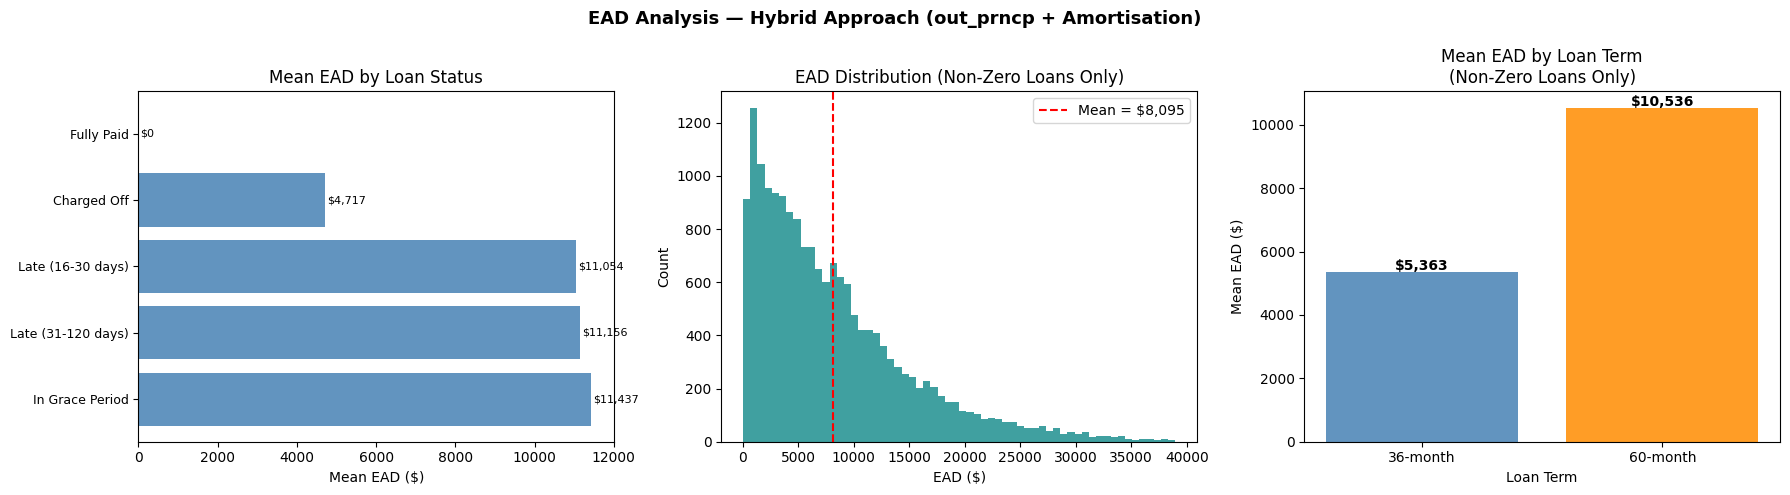

EAD distribution saved to reports/ead_distribution.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EAD Analysis — Hybrid Approach (out_prncp + Amortisation)',
             fontsize=13, fontweight='bold')

# 1. Mean EAD by loan status (active/delinquent only for clarity)
active_statuses = ['In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)',
                   'Charged Off', 'Fully Paid']
df_active = df[df['loan_status'].isin(active_statuses)]
status_ead = df_active.groupby('loan_status')['ead'].mean().sort_values(ascending=False)

bars = axes[0].barh(
    range(len(status_ead)),
    status_ead.values,
    color='steelblue',
    alpha=0.85
)
axes[0].set_yticks(range(len(status_ead)))
axes[0].set_yticklabels(status_ead.index, fontsize=9)
axes[0].set_title('Mean EAD by Loan Status')
axes[0].set_xlabel('Mean EAD ($)')
for bar, val in zip(bars, status_ead.values):
    axes[0].text(val + 50, bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}', va='center', fontsize=8)

# 2. EAD distribution (non-zero only for readability)
df_nonzero = df[df['ead'] > 0]
axes[1].hist(df_nonzero['ead'], bins=60, color='teal', alpha=0.75, edgecolor='none')
axes[1].axvline(df_nonzero['ead'].mean(), color='red', linestyle='--',
                label=f"Mean = ${df_nonzero['ead'].mean():,.0f}")
axes[1].set_title('EAD Distribution (Non-Zero Loans Only)')
axes[1].set_xlabel('EAD ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

# 3. EAD by term (non-zero only)
term_ead = df_nonzero.groupby('term')['ead'].mean()
bars2 = axes[2].bar(
    [f'{t}-month' for t in term_ead.index],
    term_ead.values,
    color=['steelblue', 'darkorange'],
    alpha=0.85
)
axes[2].set_title('Mean EAD by Loan Term\n(Non-Zero Loans Only)')
axes[2].set_xlabel('Loan Term')
axes[2].set_ylabel('Mean EAD ($)')
for bar, val in zip(bars2, term_ead.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 val + 50, f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/ead_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("EAD distribution saved to reports/ead_distribution.png")

# Cell 4 - Save EAD Results

In [6]:
df.to_csv('../data/cleaned_loan_data_with_ead.csv', index=False)

total_ead       = df['ead'].sum()
total_funded    = df['funded_amnt'].sum()
nonzero_loans   = (df['ead'] > 0).sum()

print("EAD data saved")
print(f"\n   File    : data/cleaned_loan_data_with_ead.csv")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print(f"\n   Portfolio EAD summary:")
print(f"   Total funded amount         : ${total_funded:,.0f}")
print(f"   Total EAD at risk           : ${total_ead:,.0f}")
print(f"   EAD as % of portfolio       : {total_ead/total_funded*100:.1f}%")
print(f"   Loans with EAD > 0          : {nonzero_loans:,} "
      f"({nonzero_loans/len(df)*100:.1f}%)")
print(f"\n   EAD method breakdown:")
print(f"   actual (out_prncp)          : {(df['ead_source']=='actual').sum():,} loans")
print(f"   amortised estimate          : {(df['ead_source']=='amortised').sum():,} loans")
print(f"   forced to zero (fully paid) : {(df['loan_status'].str.contains('Fully Paid', na=False)).sum():,} loans")
print(f"\nNotebook 04 complete. Next -> 05_ecl_calculation.ipynb")

EAD data saved

   File    : data/cleaned_loan_data_with_ead.csv
   Rows    : 122,216
   Columns : 37

   Portfolio EAD summary:
   Total funded amount         : $1,765,586,600
   Total EAD at risk           : $145,346,110
   EAD as % of portfolio       : 8.2%
   Loans with EAD > 0          : 17,954 (14.7%)

   EAD method breakdown:
   actual (out_prncp)          : 2,967 loans
   amortised estimate          : 119,249 loans
   forced to zero (fully paid) : 95,451 loans

Notebook 04 complete. Next -> 05_ecl_calculation.ipynb
